In [1]:
import  pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('zomato.csv')
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [3]:
df.shape

(51717, 17)

In [4]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [6]:
df.describe()

,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


In [7]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

### DROP MISSING VALUE

In [8]:
df = df.drop(columns = ['url' , 'phone' , 'dish_liked'])

In [9]:
df.columns

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'location', 'rest_type', 'cuisines', 'approx_cost(for two people)',
       'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [10]:
df.isnull().sum()

address                           0
name                              0
online_order                      0
book_table                        0
rate                           7775
votes                             0
location                         21
rest_type                       227
cuisines                         45
approx_cost(for two people)     346
reviews_list                      0
menu_item                         0
listed_in(type)                   0
listed_in(city)                   0
dtype: int64

In [11]:
df = df.dropna(subset=['rate' , 'rest_type' , 'cuisines'])

In [12]:
df.sample(3)

,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
27493,"Opposite Federal Bank, Tavarekere Main Road, B...",Royal Paris,Yes,No,3.9/5,71,BTM,Casual Dining,"North Indian, Arabian, Chinese","1,000","[('Rated 1.0', 'RATED\n it was a very bad exp...",[],Delivery,Koramangala 4th Block
49858,"Mint Plaza, Palm Avenue, Green Glen Layout, Be...",The Salad Studio,Yes,No,4.0 /5,109,Bellandur,Cafe,"Cafe, Healthy Food, Salad",400,"[('Rated 5.0', 'RATED\n Ordered Make your own...","['Veg Pasta Salad', 'Summer Sweet Corn Salad',...",Dine-out,Sarjapur Road
42597,"1A, Church Street, Bangalore",Wolf'ish,Yes,No,4.1 /5,486,Church Street,Cafe,"Cafe, American, Italian, Pizza, Burger",700,"[('Rated 4.0', 'RATED\n Tightly packed place,...",[],Delivery,MG Road


In [13]:
df.isnull().sum()

address                          0
name                             0
online_order                     0
book_table                       0
rate                             0
votes                            0
location                         0
rest_type                        0
cuisines                         0
approx_cost(for two people)    247
reviews_list                     0
menu_item                        0
listed_in(type)                  0
listed_in(city)                  0
dtype: int64

In [14]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).str.replace(',' , '')
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'] , errors = 'coerce')
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].fillna(df['approx_cost(for two people)'].median())
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(int)

In [15]:
df['rate'] = df['rate'].astype(str).apply(lambda x: x.split('/')[0].strip())

df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

df = df.dropna(subset=['rate', 'cuisines'])

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41505 entries, 0 to 51716
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   address                      41505 non-null  object 
 1   name                         41505 non-null  object 
 2   online_order                 41505 non-null  object 
 3   book_table                   41505 non-null  object 
 4   rate                         41505 non-null  float64
 5   votes                        41505 non-null  int64  
 6   location                     41505 non-null  object 
 7   rest_type                    41505 non-null  object 
 8   cuisines                     41505 non-null  object 
 9   approx_cost(for two people)  41505 non-null  int64  
 10  reviews_list                 41505 non-null  object 
 11  menu_item                    41505 non-null  object 
 12  listed_in(type)              41505 non-null  object 
 13  listed_in(city)      

In [17]:
df.isnull().sum()

address                        0
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
location                       0
rest_type                      0
cuisines                       0
approx_cost(for two people)    0
reviews_list                   0
menu_item                      0
listed_in(type)                0
listed_in(city)                0
dtype: int64

### Feature Engineering

In [18]:
df['num_cuisines'] = df['cuisines'].apply(lambda x:len(str(x).split(',')))

In [19]:
df.tail()

,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city),num_cuisines
51709,"136, SAP Labs India, KIADB Export Promotion In...",The Farm House Bar n Grill,No,No,3.7,34,Whitefield,"Casual Dining, Bar","North Indian, Continental",800,"[('Rated 4.0', 'RATED\n Ambience- Big and spa...",[],Pubs and bars,Whitefield,2
51711,"139/C1, Next To GR Tech Park, Pattandur Agraha...",Bhagini,No,No,2.5,81,Whitefield,"Casual Dining, Bar","Andhra, South Indian, Chinese, North Indian",800,"[('Rated 4.0', 'RATED\n A fine place to chill...",[],Pubs and bars,Whitefield,4
51712,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6,27,Whitefield,Bar,Continental,1500,"[('Rated 5.0', ""RATED\n Food and service are ...",[],Pubs and bars,Whitefield,1
51715,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3,236,"ITPL Main Road, Whitefield",Bar,Finger Food,2500,"[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Pubs and bars,Whitefield,1
51716,"ITPL Main Road, KIADB Export Promotion Industr...",The Nest - The Den Bengaluru,No,No,3.4,13,"ITPL Main Road, Whitefield","Bar, Casual Dining","Finger Food, North Indian, Continental",1500,"[('Rated 5.0', 'RATED\n Great ambience , look...",[],Pubs and bars,Whitefield,3


In [20]:
df['cost_per_person'] = df['approx_cost(for two people)'] / 2

In [21]:
# FOR ONE PEOPLE
def budget_category_1(cost):
  if cost <= 150:
    return 'Budget'
  elif cost <= 450:
    return 'Mid-Range'
  else:
    return 'Luxury'

df['Price_Catagory_for_1_people'] = df['cost_per_person'].apply(budget_category_1)

In [22]:
# FOR TWO PEOPLE
def budget_category_2(cost):
  if cost <= 300:
    return 'Budget'
  elif cost <= 800:
    return 'Mid-Range'
  else:
    return 'Luxury'

df['Price_Catagory_for_2_people'] = df['approx_cost(for two people)'].apply(budget_category_2)


In [23]:
df.sample(10)

,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city),num_cuisines,cost_per_person,Price_Catagory_for_1_people,Price_Catagory_for_2_people
2997,"139, 24th Main, 2nd Cross, 2nd Phase, JP Nagar...",Dal Roti,Yes,No,3.7,117,JP Nagar,Quick Bites,North Indian,150,"[('Rated 3.0', 'RATED\n Home cooked food. but...",[],Delivery,Basavanagudi,1,75.0,Budget,Budget
13648,"60/3, Ground Floor, Manipal County Road, Singa...",Royal Iceberry,Yes,No,3.4,5,Electronic City,Dessert Parlor,Desserts,200,"[('Rated 5.0', 'RATED\n Fabulous ice creams a...",[],Delivery,Electronic City,1,100.0,Budget,Budget
43475,"1/1,Markham Raod, Behind Garuda Mall,Ashoknaga...",Shan Restaurant,Yes,No,3.0,20,Brigade Road,Quick Bites,"Kerala, Chinese, South Indian, North Indian",400,"[('Rated 1.0', 'RATED\n Excellent restaurant!...","['Chicken Dry Fry Biryani', 'Mutton Biryani', ...",Dine-out,MG Road,4,200.0,Mid-Range,Mid-Range
19844,"16/33, 11th Main, 4th Block, Geetha Colony, Ja...",Rooftop Cafe,Yes,No,4.1,799,Jayanagar,Cafe,"Cafe, Fast Food, Beverages",400,"[('Rated 5.0', 'RATED\n Cheap veg cafe with g...","['French Fries', 'Masala French Fries', 'Nacho...",Delivery,Jayanagar,3,200.0,Mid-Range,Mid-Range
50932,"32/2G, NCPR Industrial Layout, Doddanakundi In...",eat.fit,Yes,No,4.4,1061,Whitefield,Delivery,"Healthy Food, North Indian, Biryani, Continent...",500,"[('Rated 4.0', 'RATED\n Eat.Fit, Whitefield, ...","[""Chef'S Special Veg Thali"", ""Chef'S Special C...",Desserts,Whitefield,5,250.0,Mid-Range,Mid-Range
21063,"178, Next To Old KEB Office, 8th F Main Road, ...",Biryanis And More,Yes,No,4.1,620,Jayanagar,Casual Dining,"Biryani, North Indian, Chinese, Andhra, South ...",750,"[('Rated 5.0', ""RATED\n Dear Biryanis and mor...","['Tandoori Chicken', 'Chicken 65', 'Chicken Lo...",Dine-out,Jayanagar,5,375.0,Mid-Range,Mid-Range
2459,"19 D Cross, 7th Main, BTM, Bangalore",Amontron,Yes,No,3.9,435,BTM,Casual Dining,Bengali,650,"[('Rated 3.0', 'RATED\n Food quality is okay....",[],Dine-out,Bannerghatta Road,1,325.0,Mid-Range,Mid-Range
14722,"21, Ground Floor, Praise the Lord Mansion, Neh...",The Mangalorean,Yes,Yes,4.1,229,Kammanahalli,Casual Dining,"Konkan, Mangalorean, Seafood",550,"[('Rated 3.0', ""RATED\n Since I've never tast...",[],Delivery,Frazer Town,3,275.0,Mid-Range,Mid-Range
46713,"3rd Floor, Food Court, Mantri Square Mall, Sam...",The Waffles Hut,Yes,No,3.6,17,Malleshwaram,Dessert Parlor,Desserts,400,"[('Rated 4.0', ""RATED\n I was looking to eat ...",[],Desserts,Rajajinagar,1,200.0,Mid-Range,Mid-Range
3246,"1/72, 27th Cross, Opposite To Janatha Bazar, 4...",Big Mishra Pedha,Yes,No,2.9,23,Jayanagar,Sweet Shop,Mithai,250,"[('Rated 1.0', 'RATED\n While the sweets and ...",[],Desserts,Basavanagudi,1,125.0,Budget,Budget


In [24]:
df['multi_cuisine'] = df['num_cuisines'].apply(lambda x: 1 if x > 1 else 0)

### Visualization

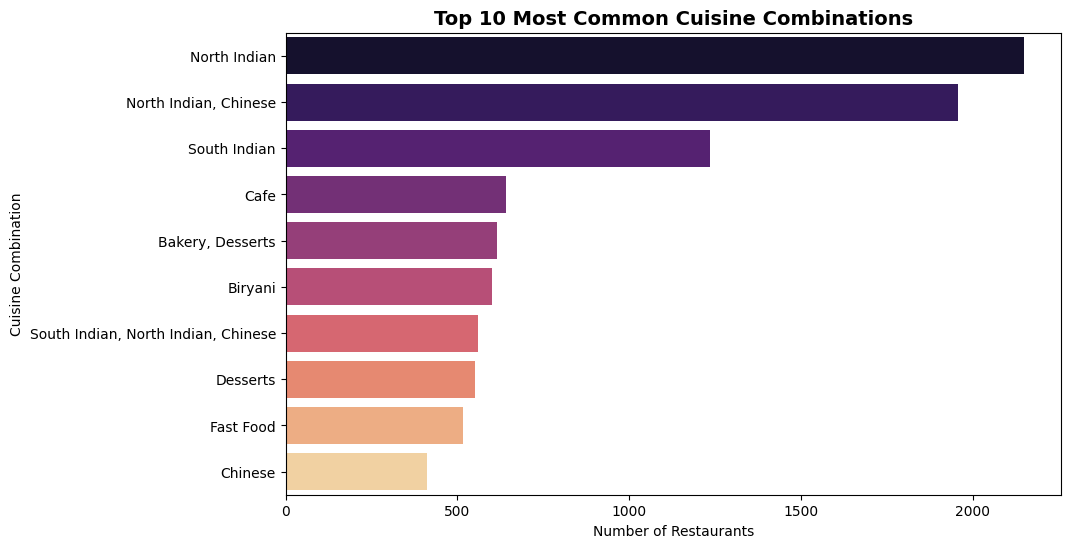

In [25]:
# Top 10 Most Common Cuisine Combinations
%matplotlib inline
plt.figure(figsize=(10, 6))
top_cuisines = df['cuisines'].value_counts().head(10)

sns.barplot(x=top_cuisines.values, y=top_cuisines.index, hue=top_cuisines.index, palette='magma',legend=False)

plt.title('Top 10 Most Common Cuisine Combinations', fontsize=14, fontweight='bold')
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine Combination')


plt.show()

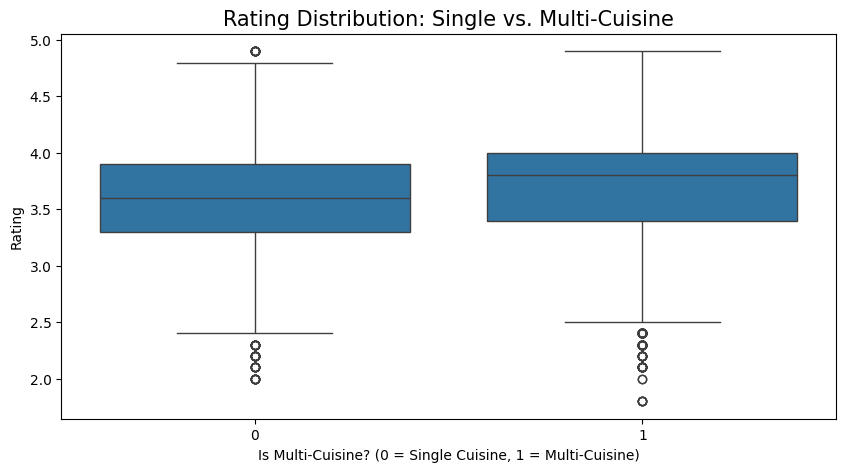

In [27]:
# Rating Single vs Multi-Cuisine

plt.figure(figsize=(10,5))

sns.boxplot(data = df , x = 'multi_cuisine' , y = 'rate' )
plt.title('Rating Distribution: Single vs. Multi-Cuisine' , fontsize = 15)
plt.xlabel('Is Multi-Cuisine? (0 = Single Cuisine, 1 = Multi-Cuisine)')
plt.ylabel('Rating')
plt.show()

In [31]:
highest_voted = df[df['votes'] == df['votes'].max()][['name', 'votes', 'rate']]
print("--- Restaurant with Highest Votes ---")
print(highest_voted.drop_duplicates(subset=['name']))


lowest_voted = df[df['votes'] == df['votes'].min()][['name', 'votes', 'rate']]
print("--- Restaurants with Lowest Votes ---")
print(lowest_voted.drop_duplicates(subset=['name']).head(5))



--- Restaurant with Highest Votes ---
                              name  votes  rate
49170  Byg Brewski Brewing Company  16832   4.9
--- Restaurants with Lowest Votes ---
                                             name  votes  rate
444                    Starlite Bakery & Fastfood      0   3.7
8267   Tangerine - Davanam Sarovar Portico Suites      0   4.0
21158                                   Lambsters      0   3.6
21167                      Ilyazsab Shawarma Cafe      0   3.6
21182                               SLV Ragigudda      0   3.7



Correlation between Votes and Rating: 0.43


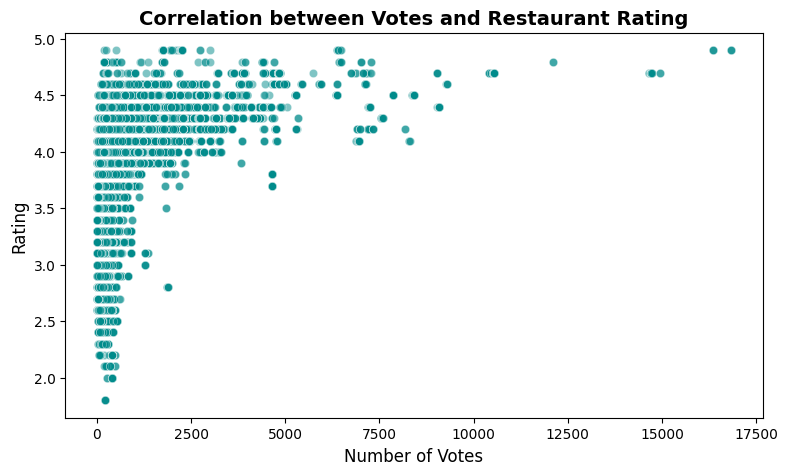

In [30]:
corr_value = df['votes'].corr(df['rate'])
print(f"\nCorrelation between Votes and Rating: {corr_value:.2f}")

plt.figure(figsize=(9, 5))
sns.scatterplot(x='votes', y='rate', data=df, alpha=0.5, color='darkcyan')

plt.title('Correlation between Votes and Restaurant Rating', fontsize=14, fontweight='bold')
plt.xlabel('Number of Votes', fontsize=12)
plt.ylabel('Rating', fontsize=12)

plt.show()

### 
* **Highest vs. Lowest Voted:** Discovered top-performing restaurants with maximum customer traction, as well as newly opened outlets with minimal votes.
* **Positive Correlation:** Analysis shows a positive correlation between `votes` and `rate`, confirming that higher-rated restaurants tend to receive significantly more user votes and social proof.
* **Customer Engagement:** Total votes serve as a strong indicator of overall restaurant popularity and brand awareness in the market.